# Metropolis-Hastings

We have to find the underlying model of our set of data, which we know is for example straight line + some noise.

To start, let's draw samples from a model $\rightarrow$ straight line + gauss errors:

$$ y = m x + b + |y*f_\text{noise}| + |y_\text{err}|$$

where we now that it should be:

$$ \cases{m = -0.9594 \\
b = 4.294 \\
f_\text{noise} = 0.534 }$$

NB errors are spreaded over a gaussian $\mathcal{N}(0,1)$


In [1]:
import numpy as np
import random
from matplotlib import pyplot as plt

In [2]:
rng = np.random.default_rng(seed=42)

In [3]:
# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

In [4]:
# Generate some synthetic data from the model.
N = 50
xobs = np.sort(10 * rng.normal(size=N))
yerr = 0.1 + .5 * rng.normal(size=N)
yobs = m_true * xobs + b_true
yobs += np.abs(f_true * yobs) * rng.standard_normal(size=N)
yobs += yerr * rng.standard_normal(size=N)
yerr = np.abs(yerr)

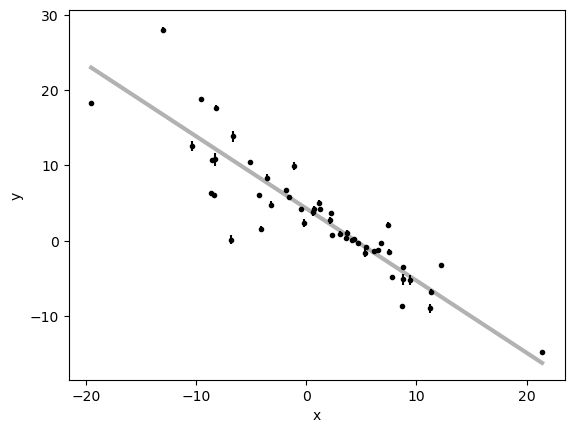

In [5]:
fig, ax = plt.subplots(1,1)

_ = ax.errorbar(xobs, yobs, yerr=yerr, fmt=".k", capsize=0)
x0 = np.linspace(xobs.min(), xobs.max(), 500)
_ = ax.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3)
_ = ax.set(xlabel='x', ylabel='y')

plt.show()

Now we want to estimate our parameters with MH algorithm
(or you can check it from [doi:10.1093/mnras/stt2190](https://academic.oup.com/mnras/article/437/4/3918/1011939)):

1. Choose $\boldsymbol{x}_0 \in \Omega_\boldsymbol{\theta}$
2. For each step ($\boldsymbol{x}_i$) propose $\boldsymbol{x}_\text{trial}$ drawn from a symmetric distribution $q(\boldsymbol{x}_\text{trial}|\boldsymbol{x}_i)$ (a gaussian centered on $x_i$)
3. Compute $k \equiv \text{min}[1, p(\boldsymbol{x}_\text{trial})/p(\boldsymbol{x}_i)]$ the new value is given by
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_i$ with probability $(1-k)$
    * $\boldsymbol{x}_{i+1} = \boldsymbol{x}_\text{trial}$ with probability $k$
4. Iterate from (2) *until convergence*

We want to explore the parameter space for $m, b, f$ iterating the MH algorithm such that we find the best parameters describing our model and compare them with the true ones. 
So 

0. at $0^{\text{th}}$ step we extract from uniform distrib three initial values $\theta_ 0 = (m_0, b_0, f_0)$ and compute their posterior probability $p_0$ as the prior times the likelihood $p_\text{prior} * \mathcal{L}$ (or sum in log). 
1. Then we extract three more val at step 1: $\theta_1 = (m_1, b_1, f_1)$ from a gaussian centered at $\theta_0$ 
2. We compute their posterior $p_1$. We then compare those two posterior, computing the ratio $\frac{p(\theta_1)}{p(\theta_0)}$ (or $p_1 - p_0$ in log)
3. We extract a random number $r$ from a uniform distribution between $0-1$, if $\log(p_1) - \log(p_0) > \log(r)$ than accept $\theta_1$ and add it to the chain with posterior probability $p_1$, otherwise we keep $\theta_0$
4. iterate steps $1 \rightarrow 3$, substituting $1 = i$ and going on with $i + 1$ until convergence! 

# Prior

My straight line has negative inclination so I suppose $m$ is negative and no less than $-2$, $b$ intercept is between $0-10$ and if I zoom in I can constrain it even more to $2-6$ but I can't say anything else about point spreading, errors...so those are my priors

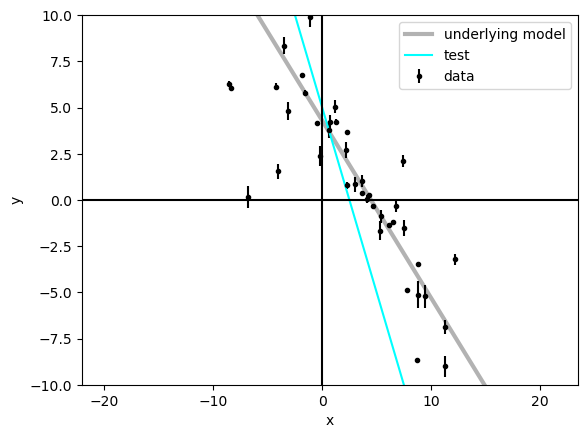

In [6]:
fig, ax = plt.subplots(1,1)

_ = ax.errorbar(xobs, yobs, yerr=yerr, fmt=".k", capsize=0, label='data')
x0 = np.linspace(xobs.min(), xobs.max(), 500)
x_grid = np.linspace(-20,20)
_ = ax.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label='underlying model')
_ = ax.plot(x_grid, x_grid*(-2) + 5, color='cyan', label='test')
_ = ax.axvline(0, color='k')
_ = ax.axhline(0, color='k')
_ = ax.set(xlabel='x', ylabel='y')
_ = ax.set_ylim(-10,10)

plt.legend()
plt.show()

In [7]:
prior = [
    [-2.0,0.0],
    [2.0,6.0],
    [-4.0, 4.0]
]

In [8]:
def log_prior(theta, prior):
    m, b, log_f = theta
    mlim, blim, flim = prior
    if mlim[0] < m < mlim[1] and blim[0] < b < blim[1] and flim[0] < log_f < flim[1]:
        return 0.0
    return -np.inf

# Likelihood

We assume a gaussian so the likelihood is 

$$ \mathcal{L}_i = \frac{1}{\sqrt{2\pi}\sigma} \text{exp}\bigg( -\frac{\big(y_i - model\big)^2 }{2 \sigma_i^2} \bigg)$$

and so $ \mathcal{L} = \prod_{i=1}^{N} \mathcal{L}_i $. In logarithm the product becomes a sum $\Sigma_{i=1}^N$ so

$$ L_i = log\mathcal{L}_i = const - \frac{log(\sigma_i)}{2}  - \frac{ \big(y_i - model \big)^2 }{2 \sigma_i^2}$$

In my data I assume both a measurement error and a nuisance parameter, that is some intrinsic error that I don't know and I don't want to estimate but I need it for my model to better fit the data, so

$$ \sigma^2 = y_\text{err}^2 + (y \cdot f)^2 $$




What if I don't consider the nuisance par in my fit?

In [9]:
def log_likelihood(theta, xx, yy, ee):
    m, b, log_f = theta
    model = m * xx + b
    sigma2 = ee**2 + model**2 * np.exp(2 * log_f)
    log_l = -0.5 * np.sum((yy - model) ** 2 / sigma2 + np.log(sigma2*2*np.pi))
    return log_l

# Posterior

Following from Bayes theorem

$$ post = prior * \mathcal{L} \rightarrow log(prior) + L $$

In [10]:
def log_probability(theta, xx, yy, ee, prior):
    lp = log_prior(theta, prior)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, xx, yy, ee)

## step 0
Draw random params from uniform distribution

In [11]:
theta_0 = [rng.uniform(np.min(prior[i]),np.max(prior[i])) for i in range(0,3)]
print("init params: ", theta_0)

p_0 = log_probability(theta_0, xobs, yobs, yerr, prior)
print("log posterior prob 0: ", p_0, "post 0: ", np.exp(p_0))

# diff sigma for param guess?
scales = [0.1, 0.5, 0.1] 
theta_1 = [rng.normal(theta_0[i], scales[i]) for i in range(3)]
print("suggested params: ", theta_1)

p_1 = log_probability(theta_1, xobs, yobs, yerr, prior)
print("log posterior prob 1: ", p_1, "post 1: ", np.exp(p_1))

p_acc = p_1 - p_0
print("acceptance log: ", p_1-p_0)

y_n = np.log(rng.uniform(0,1))
print("acceptance prob", y_n)

theta_new = []
theta_rej = []
post = []
step = []
step.append(0)
acc_count = 0

if p_acc >= y_n : 
    
    theta_new.append(theta_1)
    theta_rej.append(theta_0)
    post.append(p_1)
    acc_count += 1
    
else : 
    theta_new.append(theta_0)
    theta_rej.append(theta_1)
    post.append(p_0)
    
print("new params", theta_new, "\nstep: ", step[-1])

init params:  [-1.972127424583597, 2.918624119995421, -2.9454222577078317]
log posterior prob 0:  -3973.806293140121 post 0:  0.0
suggested params:  [-1.9077335452559112, 1.8935380694799098, -2.9502940979008434]
log posterior prob 1:  -inf post 1:  0.0
acceptance log:  -inf
acceptance prob -0.36490524061444013
new params [[-1.972127424583597, 2.918624119995421, -2.9454222577078317]] 
step:  0


## step 1
Draw new params from gaussian distrib centered on previous params

In [12]:
print("prev step params: ", theta_new[0])

theta_2 = [rng.normal(theta_new[0][i], scales[i]) for i in range(0,3)]
print("suggested params: ", theta_2)

p_2 = log_probability(theta_2, xobs, yobs, yerr, prior)

p_acc = p_2 - p_1
print("acceptance log fraction: ", p_2-p_1)

y_n = np.log(rng.uniform(0,1))
print("acceptance prob", y_n)

step.append(1)

if p_acc >= y_n : 
    
    theta_new.append(theta_2)
    theta_rej.append(theta_new[-1])
    post.append(p_2)
    acc_count += 1
    
else : 
    
    theta_new.append(theta_new[-1])
    theta_rej.append(theta_2)
    post.append(p_1)
    
print("new params", theta_new[-1], "\nstep: ", step[-1])

prev step params:  [-1.972127424583597, 2.918624119995421, -2.9454222577078317]
suggested params:  [-2.09400873062596, 2.4795479365310458, -2.978834601777913]
acceptance log fraction:  nan
acceptance prob -0.3349034862915846
new params [-1.972127424583597, 2.918624119995421, -2.9454222577078317] 
step:  1


## iterate

Now let's iterate the above for N times, drawing each step a random param from a gaussian distrib centered on the previous params guess

In [13]:
N = 100000
scales = [0.1, 0.5, 0.01]
burn = 20000

In [14]:
for i in range(len(step), N):
    # Suggested new params
    theta_prop = [rng.normal(theta_new[-1][j], scales[j]) for j in range(0,3)]
    p_prop = log_probability(theta_prop, xobs, yobs, yerr, prior)
    
    p_acc = p_prop - post[-1]
    
    if p_acc >= np.log(rng.uniform(0, 1)):
        theta_new.append(theta_prop)
        post.append(p_prop)
        acc_count += 1
    else:
        theta_new.append(theta_new[-1])
        post.append(post[-1])
        
    # Automatic tuning evry 100 step (during burn-in)
    if i < burn and i % 100 == 0:
        # Acceptance rate in laste 100 step
        if i == 100:
            last_acc_count = 0 
            
        local_acc_rate = (acc_count - last_acc_count) / 100
        last_acc_count = acc_count
        print("curr rate is: ", local_acc_rate, i)
        
        scales = np.array(scales)
        
        if local_acc_rate < 0.2:
            scales *= 0.8 
            print("reducing step to ", scales)
        elif local_acc_rate > 0.5:
            scales *= 1.2
            print("increasing step to ", scales)

curr rate is:  0.22 100
curr rate is:  0.07 200
reducing step to  [0.08  0.4   0.008]
curr rate is:  0.06 300
reducing step to  [0.064  0.32   0.0064]
curr rate is:  0.13 400
reducing step to  [0.0512  0.256   0.00512]
curr rate is:  0.13 500
reducing step to  [0.04096  0.2048   0.004096]
curr rate is:  0.19 600
reducing step to  [0.032768  0.16384   0.0032768]
curr rate is:  0.2 700
curr rate is:  0.22 800
curr rate is:  0.23 900
curr rate is:  0.29 1000
curr rate is:  0.23 1100
curr rate is:  0.24 1200
curr rate is:  0.23 1300
curr rate is:  0.25 1400
curr rate is:  0.24 1500
curr rate is:  0.15 1600
reducing step to  [0.0262144  0.131072   0.00262144]
curr rate is:  0.27 1700
curr rate is:  0.32 1800
curr rate is:  0.33 1900
curr rate is:  0.4 2000
curr rate is:  0.4 2100
curr rate is:  0.32 2200
curr rate is:  0.28 2300
curr rate is:  0.35 2400
curr rate is:  0.26 2500
curr rate is:  0.29 2600
curr rate is:  0.17 2700
reducing step to  [0.02097152 0.1048576  0.00209715]
curr rate i

In [15]:
acc__rate = acc_count/len(theta_new)
print("acceptance rate: ", acc__rate)

acceptance rate:  0.34651


In [16]:
thin = 10
theta = np.array(theta_new)
theta = theta[burn::thin]
m_fit, b_fit, f_fit = [np.mean(theta[:,j]) for j in range(0,3)]
par_fit = m_fit, b_fit, f_fit
print(par_fit)

(-0.9399315038793307, 4.182117356521524, -0.6412380305565853)


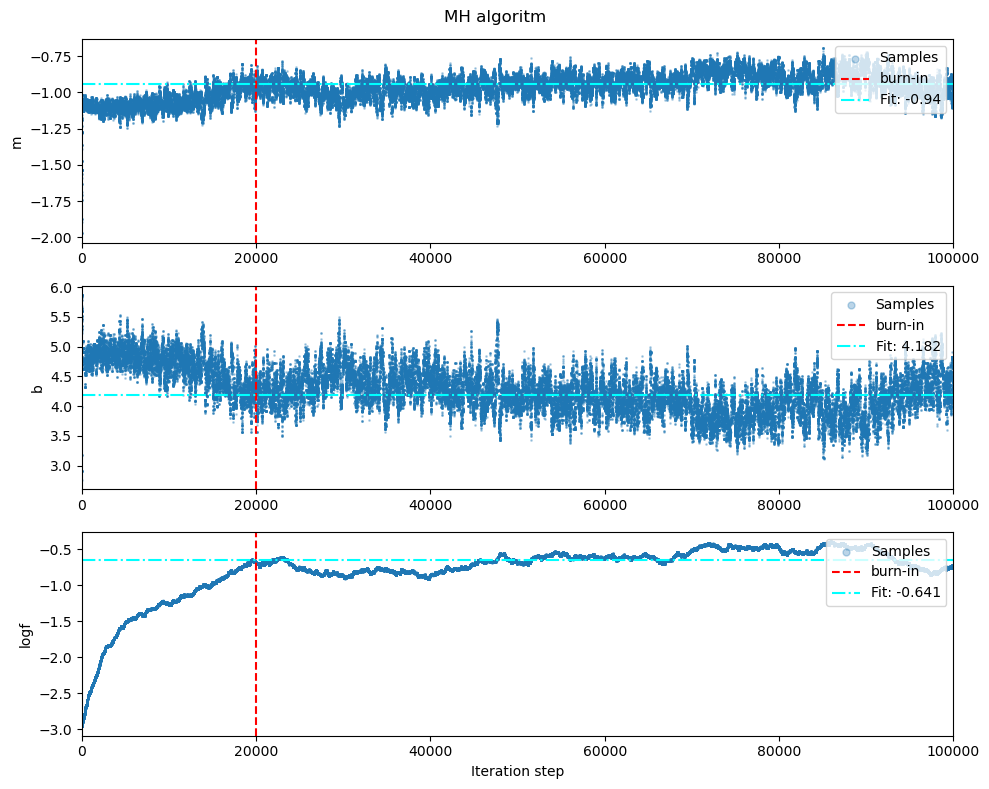

In [17]:
labels = ['m', 'b', 'logf']

fig, axs = plt.subplots(3, 1, figsize=(10, 8)) 
fig.suptitle("MH algoritm")

for i, col in enumerate(zip(*theta_new)):
    
    data = np.array(col)
    iterations = np.arange(len(data))
    
    axs[i].scatter(iterations, data, s=1, alpha=0.3, label='Samples')
    axs[i].set_ylabel(labels[i])
    axs[i].axvline(burn, color='r', linestyle='--', label='burn-in')
    axs[i].axhline(par_fit[i], color='cyan', linestyle='-.', 
                   label=f"Fit: {round(par_fit[i],3)}")
    axs[i].set_xlim(0, len(data))
    axs[i].legend(loc='upper right', markerscale=5)

plt.xlabel("Iteration step")
plt.tight_layout()
plt.show()

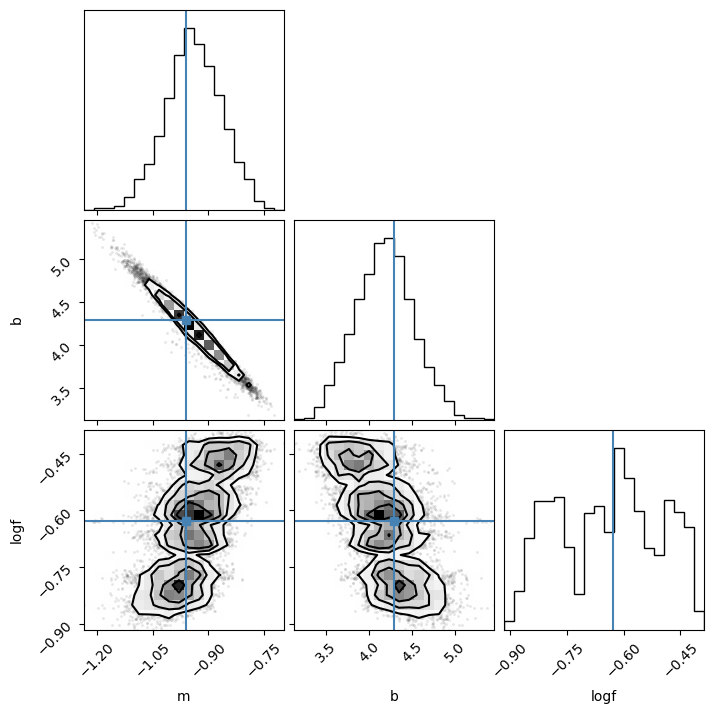

In [18]:
import corner

fig = corner.corner(
    theta,
    labels=["m", "b", "logf"],
    truths=[m_true, b_true, np.log(f_true)]
)

# Visually

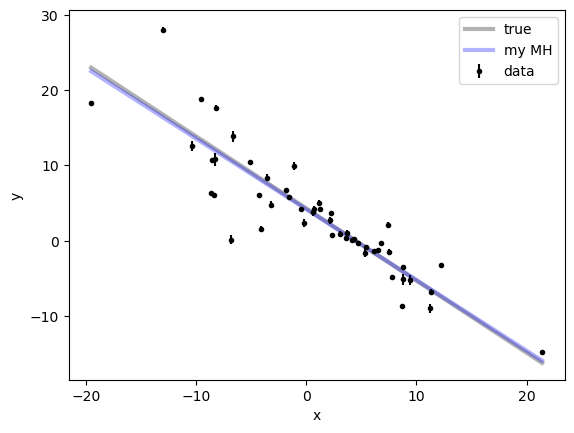

In [19]:
fig, ax = plt.subplots(1,1)

_ = ax.errorbar(xobs, yobs, yerr=yerr, fmt=".k", capsize=0, label='data')
x0 = np.linspace(xobs.min(), xobs.max(), 500)
_ = ax.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label='true')
_ = ax.plot(x0, m_fit * x0 + b_fit, "b", alpha=0.3, lw=3, label='my MH' )
_ = ax.set(xlabel='x', ylabel='y')

plt.legend()
plt.show()

In [20]:
# Test di "salto forzato"
test_theta = [-0.9, np.mean([t[1] for t in theta_new]), np.mean([t[2] for t in theta_new])]
print("Log-Prob al valore vero (-0.9):", log_probability(test_theta, xobs, yobs, yerr, prior))
print("Log-Prob al valore attuale (-1.8):", post[-1])

Log-Prob al valore vero (-0.9): -121.77339746571715
Log-Prob al valore attuale (-1.8): -110.9326108985378
